In [35]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from scipy.signal import butter, filtfilt

import numpy as np
import scipy.linalg as la
import librosa
import soundfile as sf
from pathlib import Path

# Classic filters

## Helper functions

In [36]:
L = 2048
K_RANK = 100
def define_name(recording_name, window_length, k_rank, method=""):
    return f"{recording_name}-wl{window_length}-k{k_rank}-denoised_by-{method}.wav"

def get_frequency_spectrum(audio, fs):
    """Converts time-domain audio to frequency-domain magnitudes."""
    n = len(audio)
    fft_result = np.fft.rfft(audio)
    magnitudes = np.abs(fft_result)
    # Generate the frequency axis
    frequencies = np.fft.rfftfreq(n, d=1/fs)
    return frequencies, magnitudes

def visualize_comparison(t, original, filtered, fs, title="Filter Results"):
    """Shows Time Domain and Frequency Domain comparisons."""

    freqs_orig, mag_orig = get_frequency_spectrum(original, fs)
    freqs_filt, mag_filt = get_frequency_spectrum(filtered, fs)

    fig, ax = plt.subplots(2, 1, figsize=(12, 10))
    
    ax[0].plot(t, original, label="Original", color='lightgray', alpha=0.7)
    ax[0].plot(t, filtered, label="Filtered", color='blue', linewidth=1.5)
    ax[0].set_title(f"{title}: Time Domain")
    ax[0].set_xlabel("Time (s)")
    ax[0].legend()

    ax[1].plot(freqs_orig, mag_orig, label="Original Spectrum", color='lightgray')
    ax[1].plot(freqs_filt, mag_filt, label="Filtered Spectrum", color='red')
    ax[1].set_title(f"{title}: Frequency Domain (Magnitude Spectrum)")
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_xlim(0, fs/4) # Zoom in on relevant audible range
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()

## Low-pass

In [37]:
def low_pass_workflow(audio_path, cutoff_hz=2000, order=5, visualize=True):
    audio, fs = librosa.load(audio_path, sr=None, duration=5.0) # Load 5 seconds
    t = np.linspace(0, len(audio)/fs, len(audio))
    
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_audio = filtfilt(b, a, audio)

    if visualize:
        visualize_comparison(t, audio, filtered_audio, fs, f"LPF at {cutoff_hz}Hz")

    return filtered_audio, fs

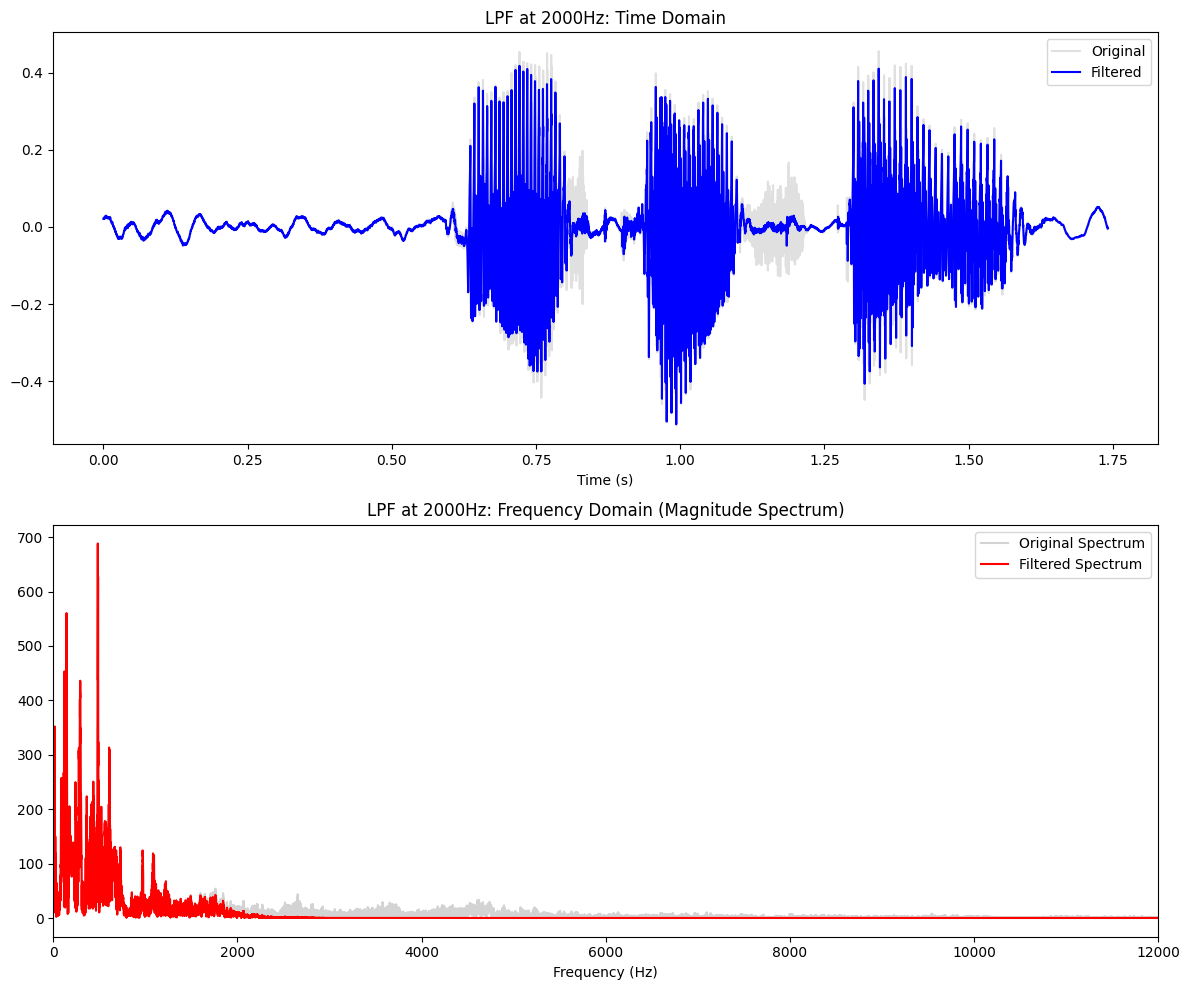

In [38]:
RECORDING_NAME = "recording-3"
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK, "LOW-PASS")}"

filtered_signal, sample_rate = low_pass_workflow(INPUT_PATH)
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, filtered_signal, sample_rate)

## High-pass

In [39]:
def high_pass_workflow(audio_path, cutoff_hz=1000, order=5, visualize=True):
    """
    Loads audio, applies a high-pass filter, and visualizes 
    the frequency-domain transformation.
    """
    audio, fs = librosa.load(audio_path, sr=None, duration=5.0)
    t = np.linspace(0, len(audio)/fs, len(audio))
    
    nyquist = 0.5 * fs
    normal_cutoff = cutoff_hz / nyquist
    
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    filtered_audio = filtfilt(b, a, audio)
    
    if visualize:
        visualize_comparison(t, audio, filtered_audio, fs, title=f"High-Pass Filter at {cutoff_hz}Hz")
    
    return filtered_audio, fs

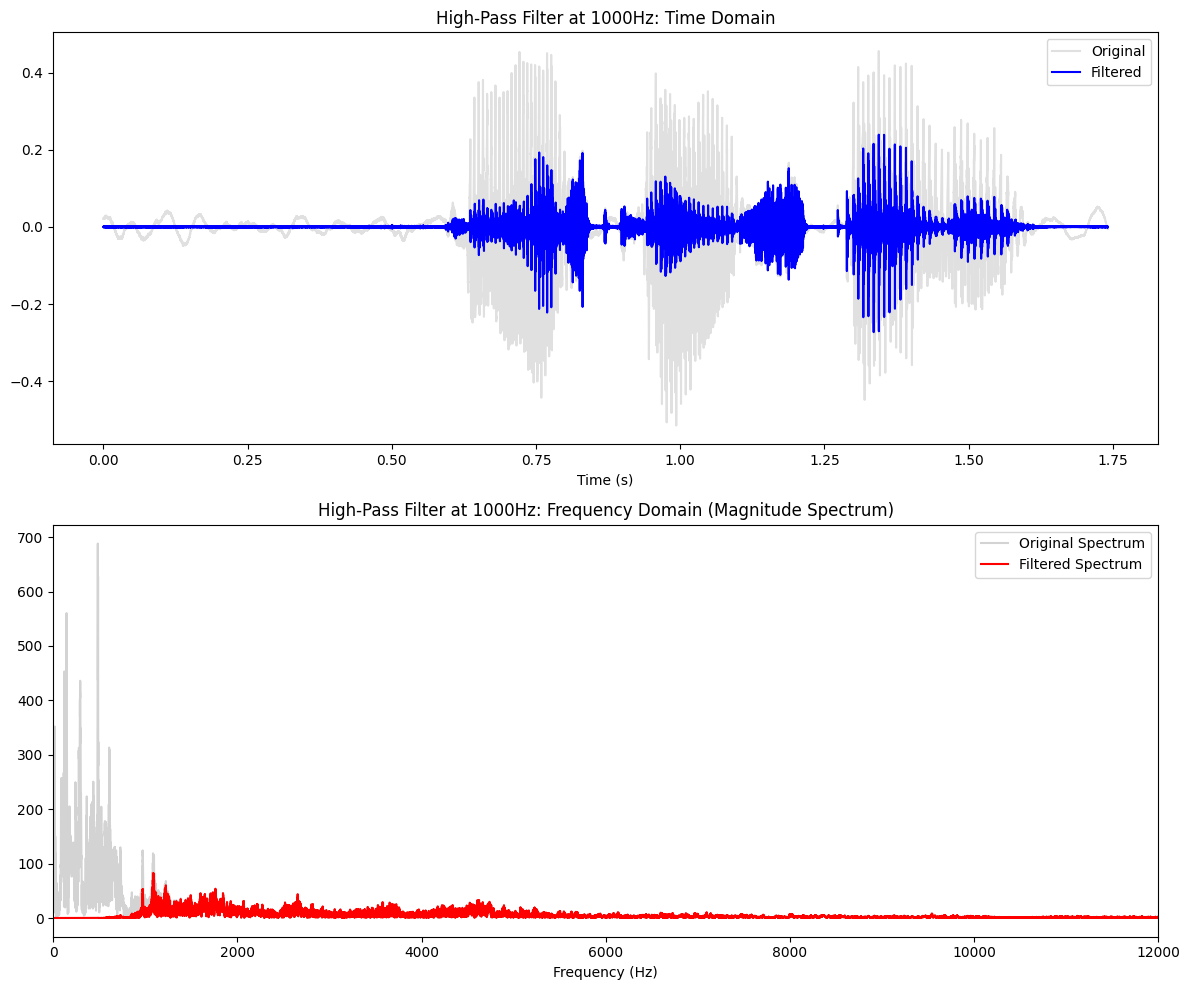

In [40]:
RECORDING_NAME = "recording-3"
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK, "HIGH-PASS")}"

filtered_signal, sample_rate = high_pass_workflow(INPUT_PATH)
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, filtered_signal, sample_rate)

## Band-pass

In [41]:
def band_pass_workflow(audio_path, low_cutoff=300, high_cutoff=3000, order=5, visualize=True):
    """
    Applies a band-pass filter to isolate frequencies between low and high cutoffs.
    """
    audio, fs = librosa.load(audio_path, sr=None, duration=5.0)
    t = np.linspace(0, len(audio)/fs, len(audio))
    nyquist = 0.5 * fs
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    
    b, a = butter(order, [low, high], btype='bandpass', analog=False)
    filtered_audio = filtfilt(b, a, audio)
    
    if visualize:
        visualize_comparison(t, audio, filtered_audio, fs, 
                            title=f"Band-Pass: {low_cutoff}Hz to {high_cutoff}Hz")
    
    return filtered_audio, fs

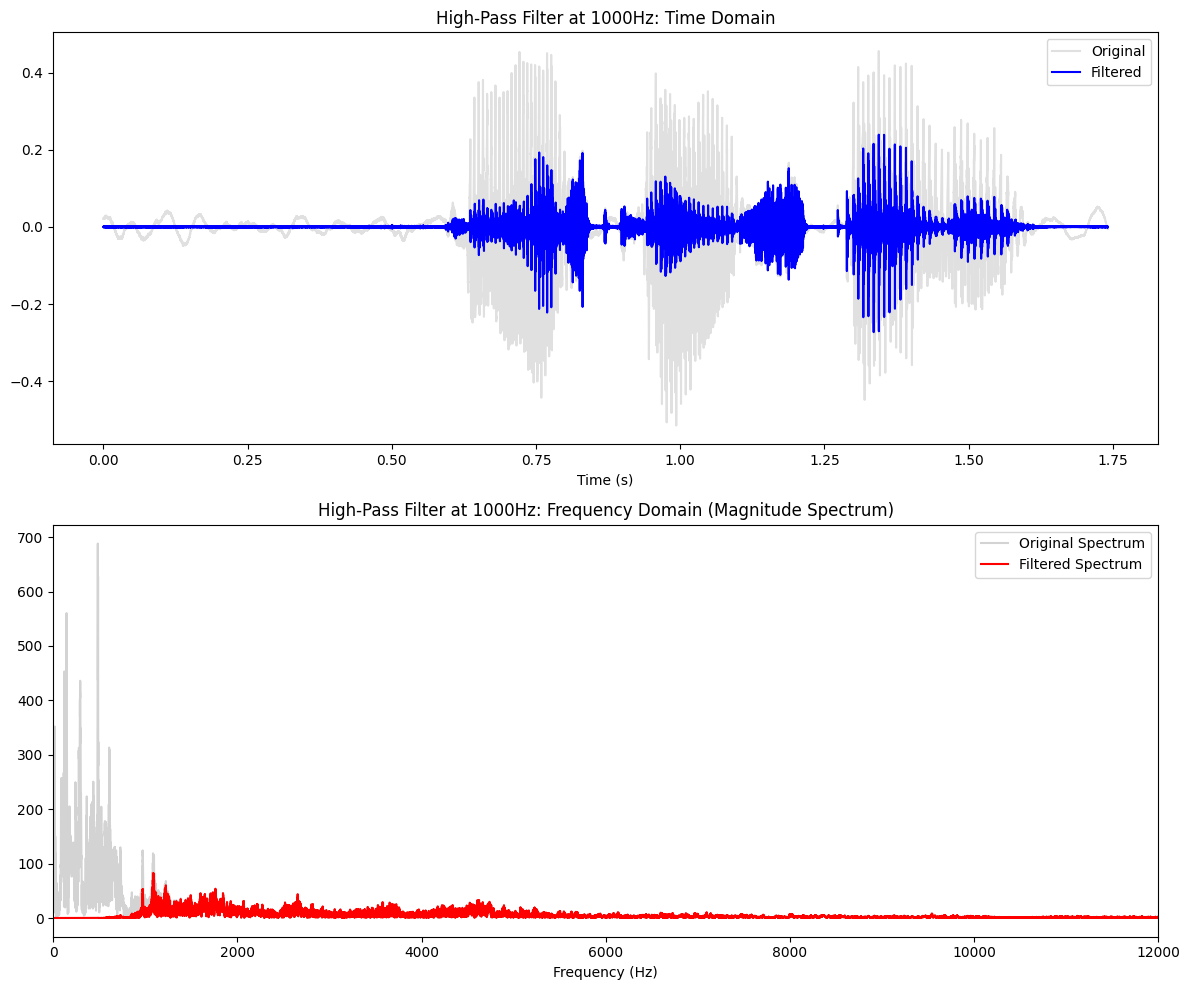

In [42]:
RECORDING_NAME = "recording-3"
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK, "BAND-PASS")}"

filtered_signal, sample_rate = high_pass_workflow(INPUT_PATH)
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, filtered_signal, sample_rate)

# Spectral methods

## Helper functions

In [43]:
L = 2048
K_RANK = 100
def define_name(recording_name, window_length, k_rank, method=""):
    return f"{recording_name}-wl{window_length}-k{k_rank}-denoised_by-{method}.wav"


def visualize_spectral_comparison(original, denoised, fs, title="Spectral Denoising Results"):
    plt.figure(figsize=(15, 12))
    
    plt.subplot(3, 1, 1)
    t = np.linspace(0, len(original)/fs, len(original))
    plt.plot(t, original, color='red', label='Original (Noisy)', alpha=0.6)
    plt.plot(t, denoised, color='blue', label='Denoised', alpha=0.8)
    plt.title(f"{title}: Time Domain Waveforms")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend(loc='upper right')

    plt.subplot(3, 1, 2)
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(original)), ref=np.max)
    librosa.display.specshow(D_orig, sr=fs, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Original Spectrogram (Noise Present)")

    plt.subplot(3, 1, 3)
    D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(denoised)), ref=np.max)
    librosa.display.specshow(D_denoised, sr=fs, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title("Denoised Spectrogram (Noise Floor Removed)")

    plt.tight_layout()
    plt.show()

In [44]:
def spectral_denoise(audio_path, noise_threshold=2.0, visualize=True):

    y, sr = librosa.load(audio_path, sr=None)
    stft = librosa.stft(y)
    magnitude, phase = librosa.magphase(stft)

    noise_sample = magnitude[:, :int(sr * 0.5 / 512)]
    noise_estimation = np.mean(noise_sample, axis=1, keepdims=True)
    magnitude_denoised = magnitude - (noise_threshold * noise_estimation)
    
    magnitude_denoised = np.maximum(magnitude_denoised, 0.0)
    stft_denoised = magnitude_denoised * phase
    y_denoised = librosa.istft(stft_denoised)

    stft_denoised = magnitude_denoised * phase
    y_denoised = librosa.istft(stft_denoised)

    # --- FIX: Match lengths for visualization ---
    # Determine the minimum length between original and processed
    min_len = min(len(y), len(y_denoised))
    y = y[:min_len]
    y_denoised = y_denoised[:min_len]

    if visualize:
        visualize_spectral_comparison(y, y_denoised, sr)
    
    return y_denoised, sr

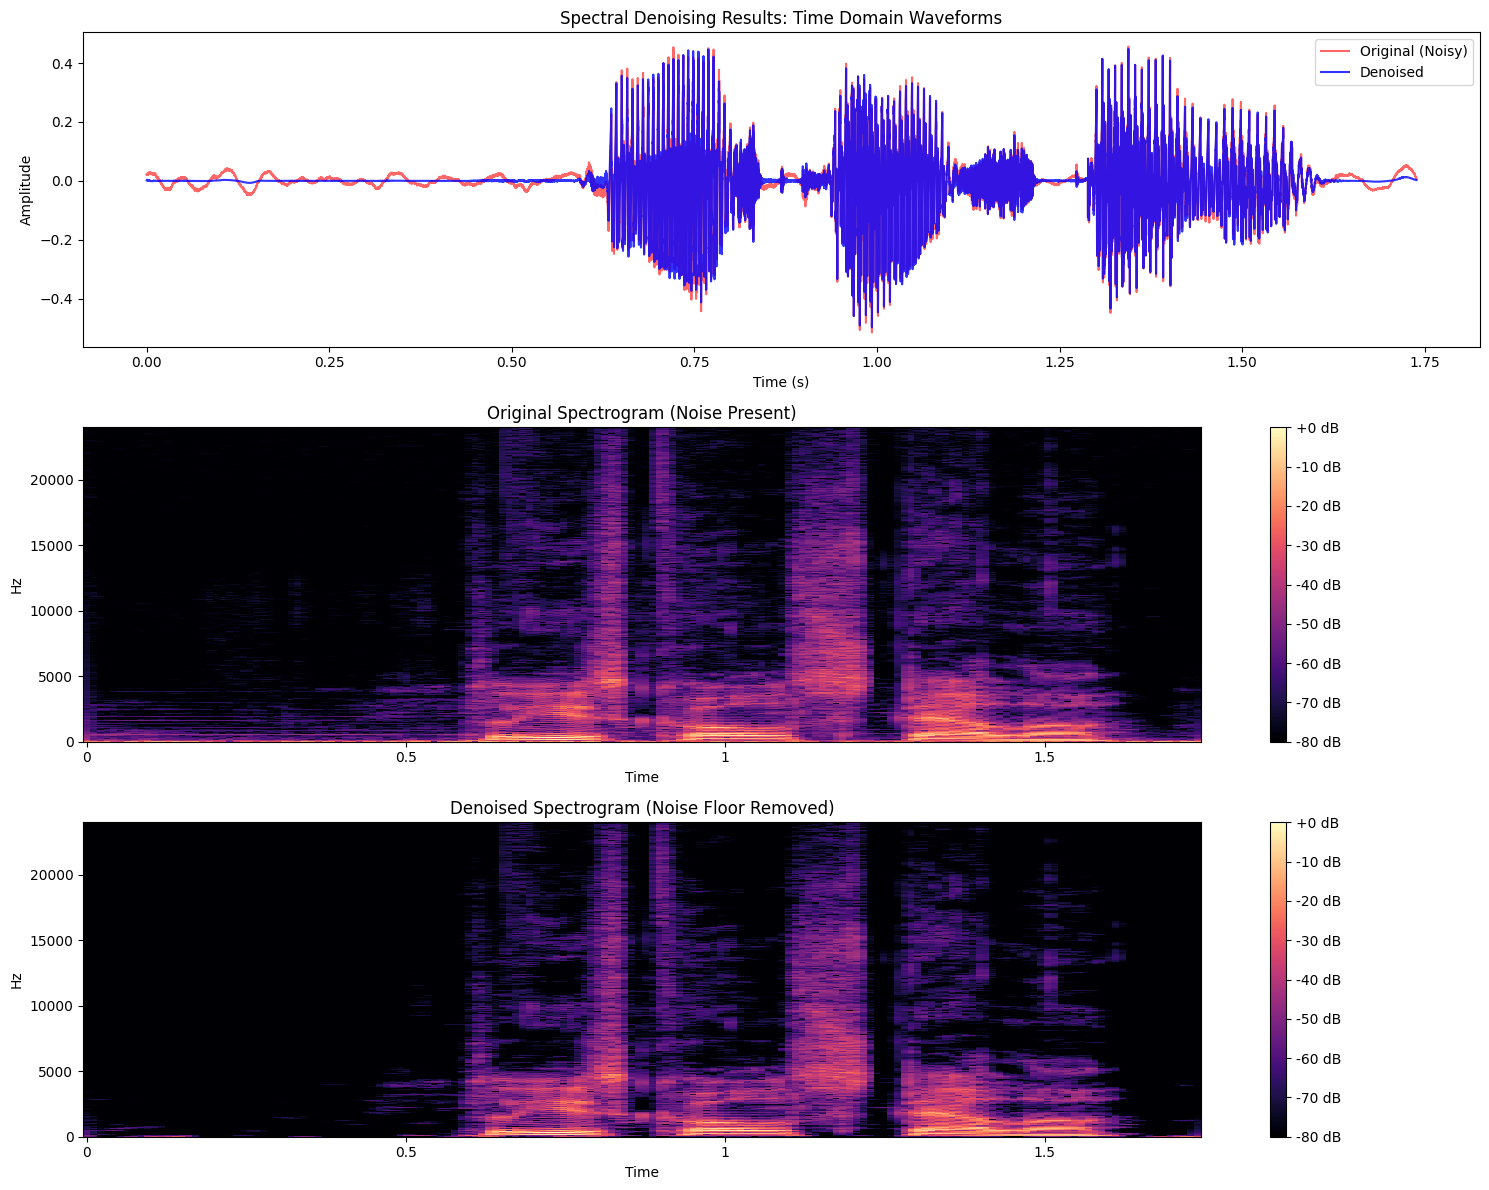

In [45]:
INPUT_PATH = f"data/input/{RECORDING_NAME}.wav"
RECORDING_NAME = "recording-3"
OUTPUT_PATH = f"data/output/{define_name(RECORDING_NAME, L, K_RANK, "SPECTRAL")}"

filtered_signal, sample_rate = spectral_denoise(INPUT_PATH)
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
sf.write(OUTPUT_PATH, filtered_signal, sample_rate)

# ML/DL

In [46]:
# Nothing here but I will do it